# Name-free labels for free-vocabulary NL→FOL translations (T7b) — dataset build demo

This notebook walks through **`data.py`** (and the `src/build_output.py` group builders it calls). Together they package the
*name-free* faithfulness labels for LLM-written first-order-logic (FOL) translations into the `exp_sel_data_out` format.

**Background.** In the *FREE* condition of R_COMP, 10 LLM slots from 9 model families translated 221 templated rule sentences
into FOL, each with its own made-up predicate names. That gives 2,652 generation records. Each one was labelled with no gold
vocabulary, using an **exhaustive, certificate-backed search over symbol maps**:
- injective renamings plus reification / merge / split / lexical-negation bridges B1–B5;
- z3 relevance and polarity prunes, and 128-model finite countermodels;
- z3 equivalence to an accepted reading of the sentence.

The search yields one of these labels:

| label | meaning |
|---|---|
| `ERROR_CERT` | no map in the family makes the candidate equivalent to any reading; a certificate backs this, so the label is final |
| `UNRESOLVED_GLOSS_NOT_RUN` | z3-equivalent under *some* map ("MAPPED"), but the paid LLM gloss check never ran (deviation D9: budget exhausted) |
| `UNPARSEABLE` / `NO_OUTPUT` | kept as rows and counted, never dropped |

`data.py` builds three groups:
1. **`rcomp_free_labels`**: one example per FREE generation record, with the label and its certificate metadata.
2. **`gloss_gate_items`**: known-answer items of the form (symbol use, proposed meaning), 7 classes. They gate the future gloss checker.
3. **`sig_soundness_replay`**: SIG rows (fixed-signature translations with known pure-z3 labels) re-run after nonce or synonym renaming, to test the search's soundness.

The original script reads `results/*.jsonl` and `work/sentences.json` from the artifact workspace. In this demo, those inputs
come from a **curated subset** in `mini_demo_data.json`: 70 FREE rows, 14 gate items and 16 SIG replay rows, plus the
sentences, seal and testability summary. The processing code is the original code, split into cells.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (version pinned by the original data.py)
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env) — used only for the results table / plots
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# --- original imports (data.py + src/build_output.py) ---
from __future__ import annotations

import json
import sys
from pathlib import Path

from loguru import logger

# --- extra imports for the notebook (results table + plots) ---
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

## Load the demo data

The notebook first tries the GitHub raw URL (for Colab) and falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-4/dataset-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["about"])
print({k: len(v) for k, v in data.items() if k != "about"})

Curated demo subset of the raw inputs that data.py / src/build_output.py turn into full_data_out.json: 70 FREE label rows (results/free_labels_v2.jsonl, stratified by label, round-robin over model family), 14 gloss-gate items (results/gate_items.json, 2 per class), 16 SIG replay rows (results/sig_replay_rows.jsonl, stratified by rename x SIG label) plus the sentences they reference, the label seal (results/seal.json) and the testability summary (results/testability_FREE_v2.json, trimmed to the keys data.py reads).
{'free_labels_v2': 70, 'gate_items': 14, 'sig_replay_rows': 16, 'sentences': 16, 'seal': 1, 'testability_FREE_v2': 3}


## Config

`data.py` has no tunable hyperparameters: it is a deterministic packaging step. The only knob in this demo is how many
source rows of each group to process. The demo file holds 70 / 14 / 16 rows. Processing is instant, so the defaults use all of
them. The original run used **all** rows of the full source files (2,652 / 840 / 4,280).

In [5]:
N_FREE = 70   # FREE label rows to package   (original: all 2,652 rows of results/free_labels_v2.jsonl)
N_GATE = 14   # gloss-gate items to package  (original: all 840 items of results/gate_items.json)
N_SIG = 16    # SIG replay rows to package   (original: all 4,280 rows of results/sig_replay_rows.jsonl)

OUT_FILE = "demo_full_data_out.json"  # original: ROOT / "full_data_out.json"

## Logging setup (from `data.py`)

This is the same loguru configuration as the original: INFO to stdout and DEBUG to `logs/data.log`. In the original, `ROOT` was
the script's directory. Here it is the notebook's working directory. The `sys.path` inserts for `src/` and `vendor/` are
not needed, because the builder functions are defined inline below.

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

SELECTED = ["rcomp_free_labels", "gloss_gate_items", "sig_soundness_replay"]

## Group 1: `rcomp_free_labels` (from `src/build_output.py`)

Each FREE generation record becomes one example:
- **`input`**: a JSON string holding the sentence text, the candidate FOL, the system / family / slot, the prompt variant and the template.
- **`output`**: the name-free label.
- **`metadata_*`**: the search evidence, for example
  - the `map_certificate` (the symbol map that makes the candidate z3-equivalent to a reading);
  - the number of maps enumerated and how many passed the fingerprint prune;
  - the counts of each non-equivalence certificate type (e.g. `count_prune_subtree`, `no_polarity_compatible_target`);
  - the `gloss_pairs` that the pending gloss check must confirm;
  - complexity strata (`words`, `word_tercile`, `nconds_weak`, `clause_type`, `nested`).

`label_binary_search_provisional` is the provisional view: ERROR = `ERROR_CERT`, MAPPED = `UNRESOLVED_GLOSS_NOT_RUN`, and
everything else is EXCLUDED. The only change from the original is the source of `rows`.

In [7]:
def md(d: dict) -> dict:
    return {f"metadata_{k}": v for k, v in d.items()}


def free_group() -> dict:
    rows = data["free_labels_v2"][:N_FREE]  # original: load_jsonl(RES / "free_labels_v2.jsonl")
    ex = []
    for r in rows:
        inp = {"text": r["text"], "candidate_fol": r["candidate_fol"], "system": r["system"], "family": r["family"],
               "slot": r["slot"], "prompt_variant": r["prompt_variant"], "condition": "FREE", "template_id": r["template_id"]}
        search_bin = {"ERROR_CERT": "ERROR", "UNRESOLVED_GLOSS_NOT_RUN": "MAPPED"}.get(r["label"], "EXCLUDED")
        meta = {
            "row_key": r["row_key"], "item_id": r["item_id"], "sentence_id": r["sentence_id"], "template_id": r["template_id"],
            "clause_type": r["clause_type"], "words": r["words"], "word_tercile": r["word_tercile"],
            "nconds_weak": r["nconds_weak"], "negated_condition": r["negated_condition"], "nested": r["nested"],
            "label_binary": r["label_binary"], "label_binary_search_provisional": search_bin,
            "label_source": r["label_source"], "search_status": r.get("search_status"),
            "matched_reading": r.get("matched_reading") or r.get("matched_reading_search"),
            "map_certificate": r.get("map_certificate"),
            "n_maps_enumerated": r.get("n_maps_enumerated"), "n_maps_fingerprint_pass": r.get("n_maps_fingerprint_pass"),
            "n_equiv_maps": r.get("n_equiv_maps"), "n_equiv_map_orbits": r.get("n_equiv_map_orbits"),
            "nonequiv_certificate_type_counts": r.get("nonequiv_certificate_type_counts"),
            "gloss_pairs": r.get("gloss_pairs"), "gloss_decision": r.get("gloss_decision"),
            "unresolved_reason": r.get("unresolved_reason"), "irrelevant_symbols": r.get("irrelevant_symbols"),
            "search_secs": r.get("search_secs"), "seen_iter3": r.get("seen_iter3"),
            "old_label_iter3": r.get("old_label_iter3"), "fold": "RCOMP_FREE"}
        ex.append({"input": json.dumps(inp, ensure_ascii=False), "output": r["label"], **md(meta)})
    return {"dataset": "rcomp_free_labels", "examples": ex}

## Group 2: `gloss_gate_items`

These are known-answer items for the gloss checker, the LLM step that decides whether a mapped predicate name *means* the
template atom. Each item pairs a candidate atom with a proposed meaning. The gold answer is **YES** for the classes
IDENT / SYN / FORM and **NO** for NONCE / DONOR / ROLE / MERGE. The checker verdicts (`haiku_verdict`, `qwen_verdict`) are still
`None` because the gate never ran (D9).

In [8]:
def gate_group() -> dict:
    items = data["gate_items"][:N_GATE]  # original: json.loads((RES / "gate_items.json").read_text())
    ex = []
    for i in items:
        inp = {"sentence": i["sentence"], "candidate_atom": i["candidate_atom"], "proposed_meaning": i["proposed_meaning"]}
        meta = {"item_id": i["item_id"], "class": i["class"], "half": i["half"], "sentence_id": i["sentence_id"],
                "template_id": i["template_id"], "note": i["note"], "prompt_version": "gloss_v1",
                "haiku_verdict": i.get("haiku_gloss_v1"), "qwen_verdict": i.get("qwen_gloss_v1"), "fold": "GLOSS_GATE"}
        ex.append({"input": json.dumps(inp, ensure_ascii=False), "output": i["gold"], **md(meta)})
    return {"dataset": "gloss_gate_items", "examples": ex}

## Group 3: `sig_soundness_replay`

SIG rows are translations with a fixed signature, so their correctness is known from pure z3. Every predicate and constant
was renamed, either to nonces (`Buzil`, `lopod`, …) or to synonyms, and the name-free search was re-run. The metadata
records three things:
- whether the **identity map** was recovered, which the soundness check needs;
- whether a **non-identity** equivalent map exists (on known-ERROR rows, this is the "rescue" the gloss check must stop);
- the oracle end-to-end label.

The sentence text comes from `sentences` (originally `work/sentences.json`).

In [9]:
def sig_group() -> dict:
    sents = data["sentences"]              # original: json.loads((WORK / "sentences.json").read_text())
    rows = data["sig_replay_rows"][:N_SIG]  # original: load_jsonl(RES / "sig_replay_rows.jsonl")
    ex = []
    for r in rows:
        inp = {"text": sents[r["sentence_id"]]["text"], "candidate_fol": r["renamed_fol"], "rename": r["rename"],
               "template_id": r["template_id"]}
        meta = {k: r[k] for k in ("row_key", "sentence_id", "slot", "template_id", "sig_matched_reading", "canon_fol",
                                  "search_status", "identity_map_found", "non_identity_map_found", "n_equiv_maps",
                                  "n_equiv_map_orbits", "n_maps_enumerated", "nonequiv_certificate_type_counts",
                                  "oracle_end_to_end_label", "in_e2e_gloss_subsample_300", "e2e_gloss_label")}
        meta["map_equiv_found"] = r["search_status"] in ("MAPPED", "READING_CHOICE")
        meta["fold"] = f"SIG_REPLAY_{r['rename'].upper()}"
        ex.append({"input": json.dumps(inp, ensure_ascii=False), "output": r["sig_label"], **md(meta)})
    return {"dataset": "sig_soundness_replay", "examples": ex}

## `main()` from `data.py`: assemble, validate, seal and write

This builds the three groups and checks the `exp_sel_data_out` shape: string `input`/`output`, and no reserved keys. It then
attaches the dataset-level metadata:
- the **label seal**: sha256 of the label vector over all rows and over the untouched subset, plus the prereg hash;
- the **testability** summary. Search-only labels have no CORRECT class, so AUROC is NOT_TESTABLE. The provisional
  ERROR_CERT-vs-MAPPED view is TESTABLE.

The seal and testability numbers describe the **full** 2,652-row dataset, not this demo subset. The only changes from the
original are the data sources and the output file name.

In [10]:
@logger.catch(reraise=True)
def main() -> None:
    # original: import build_output as B; groups = [B.free_group(), B.gate_group(), B.sig_group()]
    groups = [free_group(), gate_group(), sig_group()]
    for g in groups:
        assert g["examples"], g["dataset"]
        for e in g["examples"]:
            assert isinstance(e["input"], str) and isinstance(e["output"], str), g["dataset"]
            assert not ({"split", "dataset", "context"} & set(e)), g["dataset"]
    seal = data["seal"]["seals"][-1]        # original: json.loads((ROOT / "results" / "seal.json").read_text())["seals"][-1]
    t = data["testability_FREE_v2"]         # original: json.loads((ROOT / "results" / "testability_FREE_v2.json").read_text())
    out = {"metadata": {
        "artifact": "T7b name-free labels for free-vocabulary rule translations (run_u75jRHUss0zo, iter 4, gen_art_dataset_5)",
        "workspace": str(ROOT),
        "selection": ("the three plan groups (chosen as best 3 of 6 standardised candidates; folio / malls_test / "
                      "logicnli_test were context only: no multi-system candidates, ~36-39% wrong gold, or no FOL; their "
                      "standardised record is temp/candidates_data_out.json)"),
        "label_mode": seal["mode"],
        "status_note": ("SEARCH-ONLY labels: the paid gloss step could not run (deviation D9: run OpenRouter budget "
                        "exhausted before this artifact's first call; re-probed at packaging, still HTTP 403). ERROR_CERT is "
                        "final and certificate-backed; MAPPED rows are UNRESOLVED_GLOSS_NOT_RUN until src/resume_gloss.py "
                        "runs. metadata_label_binary_search_provisional (ERROR vs MAPPED) is a provisional view with audited "
                        "contamination (results/soundness_audit.json)."),
        "seal_all_rows_sha256": seal["label_vector_sha256_all_rows"],
        "seal_untouched_sha256": seal.get("label_vector_sha256_untouched"),
        "prereg_sha256": seal["prereg_sha256"],
        "testability_all_rows": {k: t["all_rows"][k] for k in ("n_ERROR", "n_CORRECT", "TESTABLE", "label_counts")},
        "testability_untouched": {k: t["untouched_subset"][k] for k in ("n_ERROR", "n_CORRECT", "TESTABLE", "label_counts")},
        "provisional_view_testable": {k: t["search_provisional_view"][k]["TESTABLE"] for k in ("all_rows", "untouched_subset")},
    }, "datasets": [g for g in groups if g["dataset"] in SELECTED]}
    (ROOT / OUT_FILE).write_text(json.dumps(out, ensure_ascii=False))  # original: ROOT / "full_data_out.json"
    logger.info(f"{OUT_FILE}: {[(g['dataset'], len(g['examples'])) for g in out['datasets']]}")


main()

11:49:23|INFO   |demo_full_data_out.json: [('rcomp_free_labels', 70), ('gloss_gate_items', 14), ('sig_soundness_replay', 16)]


## Results

Next we reload the packaged output and summarise it:
1. the label mix of the demo subset next to the full-dataset counts recorded in the metadata;
2. FREE labels by model family and by sentence clause type (the complexity strata);
3. the gate classes and the SIG replay outcomes;
4. one example of each FREE label, with its certificate evidence.

In [11]:
out = json.loads((ROOT / OUT_FILE).read_text())
meta = out["metadata"]
G = {g["dataset"]: g["examples"] for g in out["datasets"]}
print("label_mode:", meta["label_mode"], "| seal (all rows):", meta["seal_all_rows_sha256"][:16], "...")
print("provisional ERROR_CERT-vs-MAPPED view testable:", meta["provisional_view_testable"])

# 1) label mix: demo subset vs full dataset
full_counts = meta["testability_all_rows"]["label_counts"]
demo_counts = Counter(e["output"] for e in G["rcomp_free_labels"])
tab = pd.DataFrame({"full dataset (2,652 rows)": full_counts, "demo subset": dict(demo_counts)}).fillna(0).astype(int)
tab["full %"] = (100 * tab.iloc[:, 0] / tab.iloc[:, 0].sum()).round(1)
print("\nFREE label counts")
print(tab.to_string())

# 2) per-family / per-clause-type breakdown of the demo FREE rows
free = pd.DataFrame([{**json.loads(e["input"]), "label": e["output"],
                      "clause_type": e["metadata_clause_type"], "words": int(e["metadata_words"]),
                      "prov": e["metadata_label_binary_search_provisional"],
                      "n_maps_enumerated": e["metadata_n_maps_enumerated"]} for e in G["rcomp_free_labels"]])
by_fam = pd.crosstab(free["family"], free["label"])
by_clause = pd.crosstab(free["clause_type"], free["label"])
print("\nDemo FREE rows by family\n", by_fam.to_string())

# 3) gate and SIG replay
gate = pd.DataFrame([{"class": e["metadata_class"], "gold": e["output"], "half": e["metadata_half"]} for e in G["gloss_gate_items"]])
sig = pd.DataFrame([{"rename": e["metadata_fold"], "sig_label": e["output"], "search_status": e["metadata_search_status"],
                     "map_equiv_found": e["metadata_map_equiv_found"]} for e in G["sig_soundness_replay"]])
print("\nGate items (class -> gold)\n", gate.groupby(["class", "gold"]).size().to_string())
print("\nSIG replay: known SIG label vs whether an equivalent map was found\n",
      pd.crosstab([sig["rename"], sig["sig_label"]], sig["map_equiv_found"]).to_string())

label_mode: search_only | seal (all rows): 9609ebbb725832c4 ...
provisional ERROR_CERT-vs-MAPPED view testable: {'all_rows': True, 'untouched_subset': True}

FREE label counts
                          full dataset (2,652 rows)  demo subset  full %
ERROR_CERT                                      759           25    28.6
UNRESOLVED_GLOSS_NOT_RUN                       1506           30    56.8
UNPARSEABLE                                     188            7     7.1
NO_OUTPUT                                       199            8     7.5

Demo FREE rows by family
 label          ERROR_CERT  NO_OUTPUT  UNPARSEABLE  UNRESOLVED_GLOSS_NOT_RUN
family                                                                     
cohere                  3          0            1                         4
deepseek                3          0            1                         4
google-gemini           3          0            1                         4
google-gemma            3          0            1   

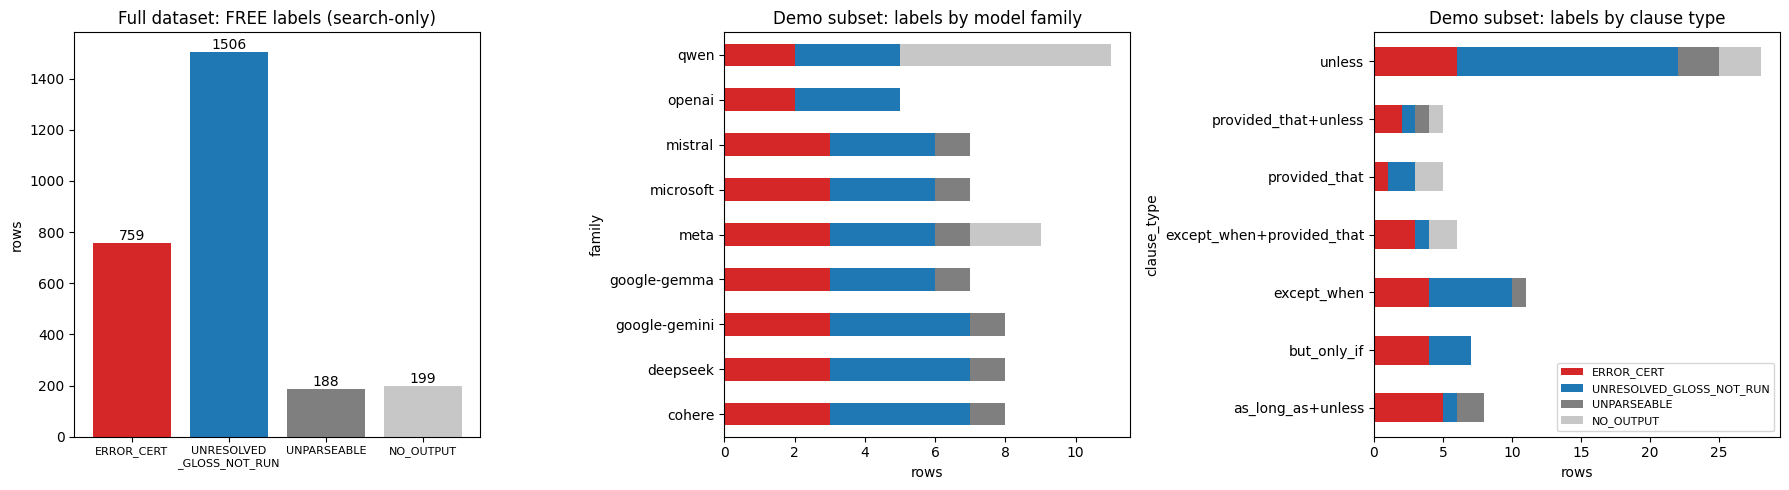

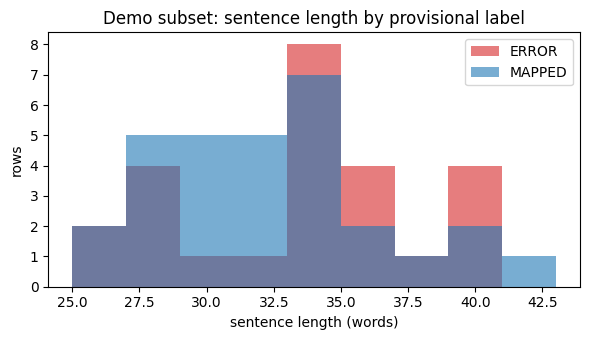

In [12]:
colors = {"ERROR_CERT": "#d62728", "UNRESOLVED_GLOSS_NOT_RUN": "#1f77b4", "UNPARSEABLE": "#7f7f7f", "NO_OUTPUT": "#c7c7c7"}
order = [c for c in colors if c in by_fam.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# (a) full-dataset label distribution from the sealed metadata
ax = axes[0]
ax.bar([k.replace("_GLOSS", "\n_GLOSS") for k in full_counts], list(full_counts.values()), color=[colors[k] for k in full_counts])
ax.set_title("Full dataset: FREE labels (search-only)")
ax.set_ylabel("rows"); ax.tick_params(axis="x", labelsize=8)
for i, v in enumerate(full_counts.values()): ax.text(i, v, str(v), ha="center", va="bottom")
# (b) demo rows by model family
by_fam[order].plot(kind="barh", stacked=True, ax=axes[1], color=[colors[c] for c in order], legend=False)
axes[1].set_title("Demo subset: labels by model family"); axes[1].set_xlabel("rows")
# (c) demo rows by clause type (sentence complexity stratum)
by_clause[order].plot(kind="barh", stacked=True, ax=axes[2], color=[colors[c] for c in order])
axes[2].set_title("Demo subset: labels by clause type"); axes[2].set_xlabel("rows")
axes[2].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

# sentence length vs provisional label (ERROR_CERT vs MAPPED)
fig, ax = plt.subplots(figsize=(6, 3.5))
bins = range(free["words"].min(), free["words"].max() + 2, 2)  # shared bins for both classes
for lab, c in [("ERROR", "#d62728"), ("MAPPED", "#1f77b4")]:
    ax.hist(free.loc[free["prov"] == lab, "words"], bins=bins, alpha=0.6, label=lab, color=c)
ax.set_xlabel("sentence length (words)"); ax.set_ylabel("rows"); ax.legend()
ax.set_title("Demo subset: sentence length by provisional label")
plt.tight_layout(); plt.show()

In [13]:
# One packaged FREE example of each label, with the search evidence behind it
for lab in ["ERROR_CERT", "UNRESOLVED_GLOSS_NOT_RUN", "UNPARSEABLE", "NO_OUTPUT"]:
    e = next((e for e in G["rcomp_free_labels"] if e["output"] == lab), None)
    if e is None: continue
    inp = json.loads(e["input"])
    print(f"=== {lab}  ({inp['system']}, {inp['prompt_variant']}, template {inp['template_id']})")
    print("TEXT:     ", inp["text"])
    print("CANDIDATE:", inp["candidate_fol"])
    print("maps enumerated:", e["metadata_n_maps_enumerated"], "| equivalent maps:", e["metadata_n_equiv_maps"],
          "| matched reading:", e["metadata_matched_reading"])
    print("non-equivalence certificates:", e["metadata_nonequiv_certificate_type_counts"])
    if e["metadata_map_certificate"]:
        print("map certificate:", json.dumps(e["metadata_map_certificate"], ensure_ascii=False)[:400])
    if e["metadata_gloss_pairs"]:
        print("gloss pairs pending check:", json.dumps(e["metadata_gloss_pairs"], ensure_ascii=False)[:300])
    print()

=== ERROR_CERT  (G9:cohere/command-r7b-12-2024, fewshot_v1, template T8)
TEXT:      If a tree records videos, contains manuscripts, and has cleared its orbit of other debris, then the tree is covered in sugar, but only if the tree is in the Croton River watershed.
CANDIDATE: (∀x (Records(x, videos) ∧ Contains(x, manuscripts) ∧ ClearedOrbit(x) → CoveredIn(x, sugar))) ↔ In(x, crotonRiverWatershed)
maps enumerated: 0 | equivalent maps: 0 | matched reading: None
non-equivalence certificates: {'no_polarity_compatible_target': 8}

=== UNRESOLVED_GLOSS_NOT_RUN  (G9:cohere/command-r7b-12-2024, fewshot_v1, template T9)
TEXT:      No piece of furniture that is open to the public, that is controlled by managers, and that relies on electric power for propulsion is created using digital tools, except when the piece of furniture is made in Maranello.
CANDIDATE: ∀x (PieceOfFurniture(x) ∧ OpenToPublic(x) ∧ ControlledByManagers(x) ∧ RelyOnElectricPower(x) → ¬CreatedUsingDigitalTools(x) ⊕ MadeIn(x, mara